# 02 - Model Training
**Smart Waste Classification System using CNN**

This notebook builds and trains a simple CNN model on the preprocessed TrashNet data (Cardboard, Glass, Metal).

In [13]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

In [14]:
# Load preprocessed data
X_train = np.load("../dataset/X_train.npy")
X_val = np.load("../dataset/X_val.npy")
y_train = np.load("../dataset/y_train.npy")
y_val = np.load("../dataset/y_val.npy")

CLASSES = ["cardboard", "glass", "metal"]
NUM_CLASSES = len(CLASSES)
IMG_SIZE = X_train.shape[1]

print("Train shape:", X_train.shape, "Val shape:", X_val.shape)

Train shape: (919, 128, 128, 3) Val shape: (197, 128, 128, 3)


In [15]:
# Build a simple CNN model
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,027 (12.61 MB)

 Trainable params: 3,305,027 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Train the model
EPOCHS = 30
BATCH_SIZE = 32

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

Epoch 1/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 27s 819ms/step - accuracy: 0.5256 - loss: 0.9768 - val_accuracy: 0.5736 - val_loss: 0.8515
Epoch 2/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 21s 722ms/step - accuracy: 0.6681 - loss: 0.7763 - val_accuracy: 0.6345 - val_loss: 0.7286
Epoch 3/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 19s 654ms/step - accuracy: 0.7127 - loss: 0.6426 - val_accuracy: 0.6345 - val_loss: 0.7174
Epoch 4/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 570ms/step - accuracy: 0.7541 - loss: 0.5961 - val_accuracy: 0.7259 - val_loss: 0.6441
Epoch 5/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 587ms/step - accuracy: 0.7563 - loss: 0.5709 - val_accuracy: 0.7208 - val_loss: 0.6637
Epoch 6/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 27s 811ms/step - accuracy: 0.8030 - loss: 0.4761 - val_accuracy: 0.7259 - val_loss: 0.7129
Epoch 7/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 571ms/step - accuracy: 0.8074 - loss: 0.4543 - val_accuracy: 0.7462 - val_loss: 0.7002
Epoch 8/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 14s 482ms/step - accuracy: 0.8477 - loss: 0.3821 - val_accu

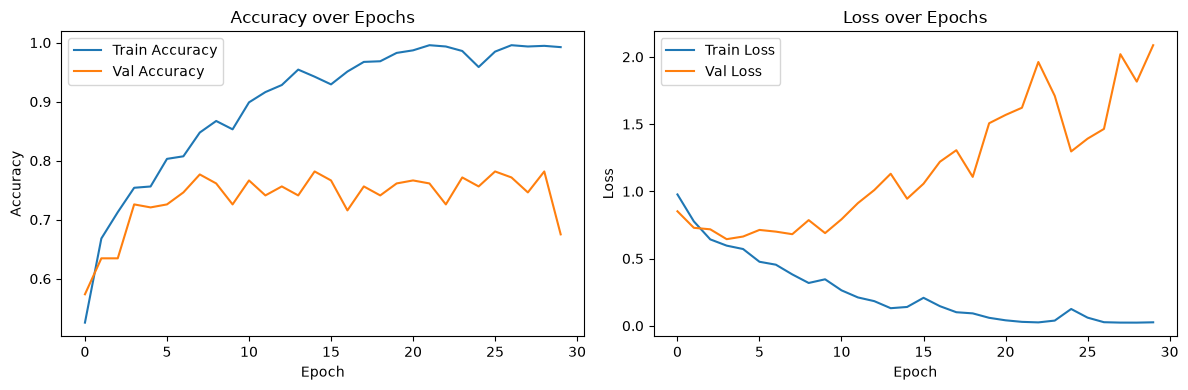

In [17]:
# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.savefig("../images/training_plots/accuracy_loss_curves.png")
plt.show()

In [18]:
# Save the trained model
model.save("../models/waste_classifier_model.h5")
print("Model saved to ../models/waste_classifier_model.h5")

Model saved to ../models/waste_classifier_model.h5


In [19]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPU Devices:", tf.config.list_physical_devices("GPU"))

TensorFlow Version: 2.21.0
GPU Devices: []


In [20]:
pip show tensorflow

Name: tensorflow
Version: 2.21.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages
Requires: absl-py, astunparse, flatbuffers, gast, google_pasta, grpcio, h5py, keras, libclang, ml_dtypes, numpy, opt_einsum, packaging, protobuf, requests, setuptools, six, termcolor, typing_extensions, wrapt
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [21]:
pip show tensorflow-intel

Note: you may need to restart the kernel to use updated packages.
